In [1]:
from ProjectFunctions import *

# Compare the mutual information to correlation functions for the NNTFIM

In [2]:
length = 8

combinations = []
physdist = []
# Generate all possible pairs of positions as well as the physical distance between spins
for i in range(length):
    for j in range(i + 1, length):
        combinations.append([i, j])
        physdist.append(j-i)


#Generate the ising model hamiltonian and find its groundstate
H = ising_model_hamiltonian(length,1,0.5,0)
E, psi = H.groundstate()


#calculate the correlation function values/distances and the mutual info values/distances
minfo = []
correlationfuncvals1, distances1 = correlation_function(length, psi, 0)
correlationfuncvals2, distances2 = correlation_function(length, psi, 1)
#mutual information is calculated in a loop over all spin combinations
for j in range(length):
        for k in range(j + 1, length):
            mutualinfo, distance = mutual_info(length, psi, [j], [k])
            minfo.append(mutualinfo)

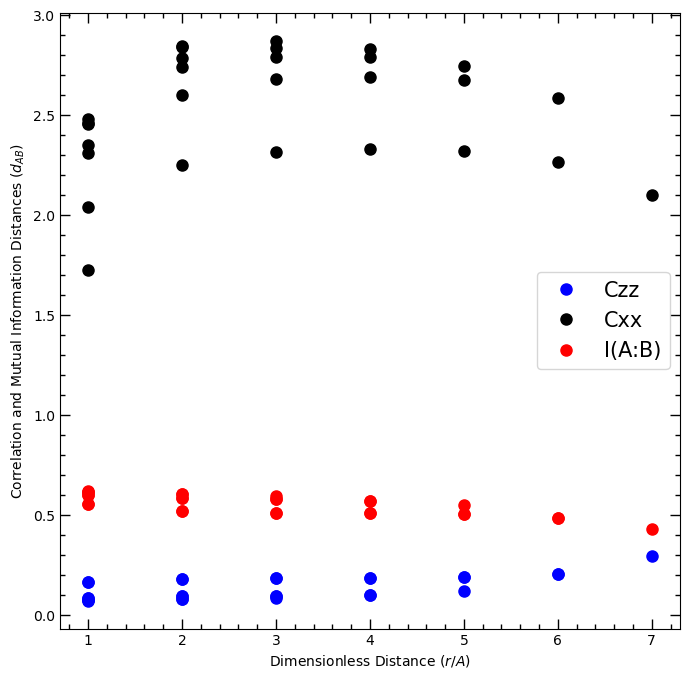

In [3]:
#plot the above calculated values
fig, ax = plt.subplots(figsize=(8,8))
plt.rcParams.update({'font.size': 15})
p1 = plt.plot(physdist, distances1, 'ob', label = 'Czz', markersize = 8)
p2 = plt.plot(physdist, distances2, 'ok', label = 'Cxx', markersize = 8)
p2 = plt.plot(physdist, minfo, 'or', label = 'I(A:B)', markersize = 8)
# label the axes
ax.set_xlabel(r"Dimensionless Distance ($r/A$)")
ax.set_ylabel(r"Correlation and Mutual Information Distances ($d_{AB}$)")

# set the tick mark parameters
ax.minorticks_on()
ax.tick_params(which='both',direction="in",width=1)
ax.tick_params(which='major',length=7)
ax.tick_params(which='minor',length=3.5)
ax.xaxis.set_ticks_position('both')
ax.yaxis.set_ticks_position('both')
plt.legend()
#plt.savefig("Comparing Czz, Cxx, Mutual Info.pdf")
plt.show()

# Mutual Information distance for a long range model with decaying interaction

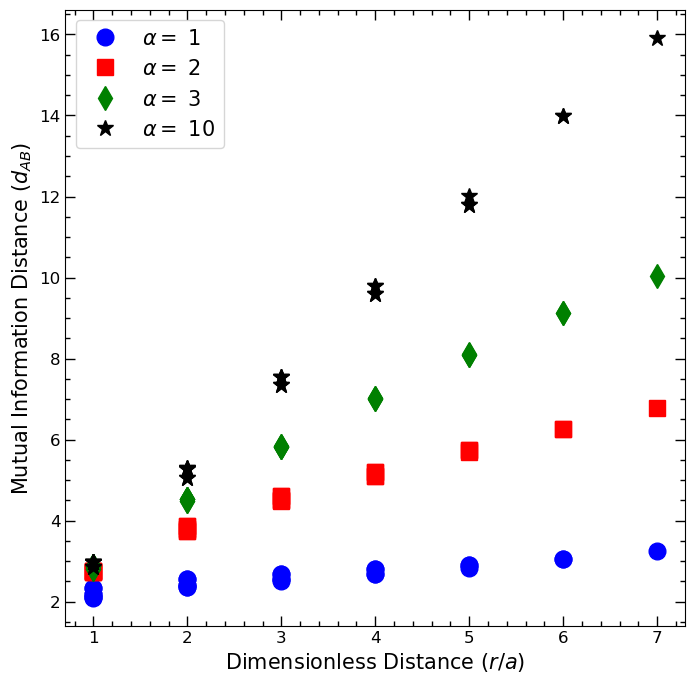

In [6]:
length = 8
#the list of interaction strengths
p = [1, 2, 3, 10]
#create the plot
colors = ['ob', 'sr', 'dg', '*k']

fig, ax = plt.subplots(figsize=(8,8))
plt.rcParams.update({'font.size': 12})
# label the axes
ax.set_xlabel(r"Dimensionless Distance ($r/a$)", fontsize = 15)
ax.set_ylabel(r"Mutual Information Distance ($d_{AB}$)", fontsize = 15)

# set the tick mark parameters
ax.minorticks_on()
ax.tick_params(which='both',direction="in",width=1)
ax.tick_params(which='major',length=7)
ax.tick_params(which='minor',length=3.5)
ax.xaxis.set_ticks_position('both')
ax.yaxis.set_ticks_position('both')

#loop over each interaction strength to find the mutual info for that model
alldist = {}
for i in range(len(p)):
    distancelist = []
    #generate the hamiltonian and find its groundstate
    H = varying_range_hamiltonian(length,1,p[i],0.1)
    E, psi = H.groundstate()
    #loop to find the mutual info
    for d in range(length):
            for f in range(d + 1, length):
                minfo, distance = mutual_info(length, psi, [d], [f])
                distancelist.append(distance)
    alldist.update({p[i]:distancelist})
    #plot the data
    plt.plot(physdist, alldist[p[i]], colors[i], label = r'$\alpha =$ ' + str(p[i]), markersize=12)
plt.legend(fontsize = 15)
#plt.savefig("Mutual Info Distance vs Physical Distance for Varied Alpha.pdf")
plt.show()